<a href="https://colab.research.google.com/github/ek182238/CSC349/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1
Load the dataset into a Pandas DataFrame.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for step 4
from sklearn.impute import SimpleImputer

# for step 5
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# for step 6
from sklearn.linear_model import SGDClassifier

# for step 7
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Task 2
Use structural inspection methods (head(), info(), describe()) to analyze features such as tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod.

In [66]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [68]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Task 3
Drop any non-informative identifiers (such as customerID).

In [69]:
df = df.drop(columns=['customerID'])

# Task 4
Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [70]:
print(df.isna().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [71]:
# The data type for TotalCharges is object, but the values are numerical.
# So I made a variable that turns the numeric values into floats
# and turned the non-numeric values (whitespace strings) into NaN.
# Now it shows up as 11 missing values
total_charges_nums = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(total_charges_nums.isna().sum())

11


In [72]:
# Now the data is numerical for TotalCharges.
# I replaced the missing values with 0 as the imputation strategy
df['TotalCharges'] = total_charges_nums
imputer = SimpleImputer(strategy='constant', fill_value=0)
df['TotalCharges'] = imputer.fit_transform(df[['TotalCharges']])
print(df.isna().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [73]:
# checking that the TotalCharges data type is numerical now
print(df['TotalCharges'].dtype)

float64


# Task 5
Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and encoding (OneHotEncoder) to categorical columns.

In [74]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify numeric & categorical features
numeric_data = X.select_dtypes(include=['int64', 'float64'])
categorical_data = X.select_dtypes(include=['object'])

print("Numerical:", numeric_data)
print("Categorical:", categorical_data)

Numerical:       SeniorCitizen  tenure  MonthlyCharges  TotalCharges
0                 0       1           29.85         29.85
1                 0      34           56.95       1889.50
2                 0       2           53.85        108.15
3                 0      45           42.30       1840.75
4                 0       2           70.70        151.65
...             ...     ...             ...           ...
7038              0      24           84.80       1990.50
7039              0      72          103.20       7362.90
7040              0      11           29.60        346.45
7041              1       4           74.40        306.60
7042              0      66          105.65       6844.50

[7043 rows x 4 columns]
Categorical:       gender Partner Dependents PhoneService     MultipleLines  \
0     Female     Yes         No           No  No phone service   
1       Male      No         No          Yes                No   
2       Male      No         No          Yes             

In [98]:
# After isolating the numerical & categorical data, I used
# a ColumnTransformer and applied StandardScaler to scale
# numerical data and OneHotEncoder for categorical data.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_data.columns),
        ('cat', OneHotEncoder(), categorical_data.columns)
    ])

# Task 6
Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.

In [99]:
classifier = SGDClassifier(
    loss='log_loss',
    random_state=42
)

# Pipeline that uses the preprocessor and SGDClassifier
# to predict data
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])

# Task 7
Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.

Confusion Matrix for 80/20 split:
[[927 109]
 [158 215]]


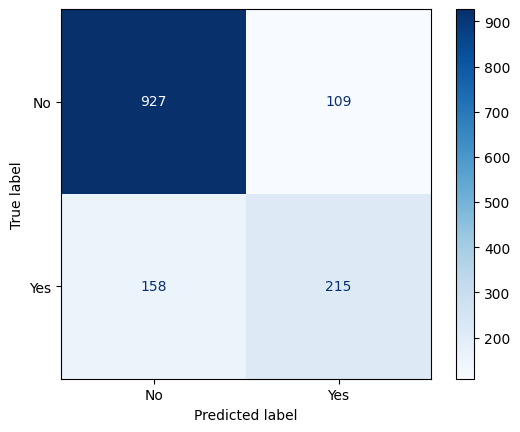


Classification Report for 80/20 split:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1036
         Yes       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.81      0.81      1409



In [103]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_predict = pipeline.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_predict)
print("Confusion Matrix for 80/20 split:")
print(conf_matrix)

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap='Blues')
plt.show()

# Classification Report
class_report = classification_report(y_test, y_predict)
print("\nClassification Report for 80/20 split:")
print(class_report)

# ROC-AUC curve

Confusion Matrix for 70/30 split:
[[1473   66]
 [ 391  183]]


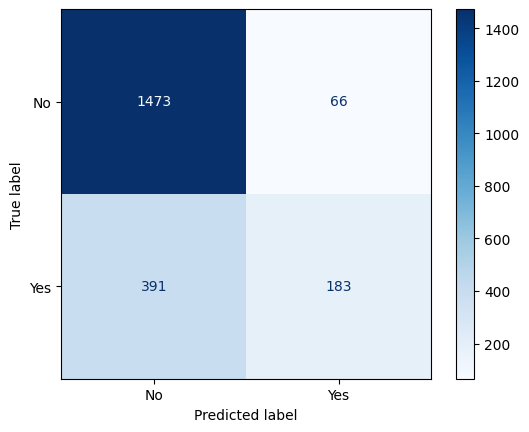


Classification Report for 70/30 split:
              precision    recall  f1-score   support

          No       0.79      0.96      0.87      1539
         Yes       0.73      0.32      0.44       574

    accuracy                           0.78      2113
   macro avg       0.76      0.64      0.66      2113
weighted avg       0.78      0.78      0.75      2113



In [104]:
# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
pipeline.fit(X_train, y_train)
y_predict = pipeline.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_predict)
print("Confusion Matrix for 70/30 split:")
print(conf_matrix)

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap='Blues')
plt.show()

# Classification Report
class_report = classification_report(y_test, y_predict)
print("\nClassification Report for 70/30 split:")
print(class_report)

Confusion Matrix for 60/40 split:
[[1705  364]
 [ 207  542]]


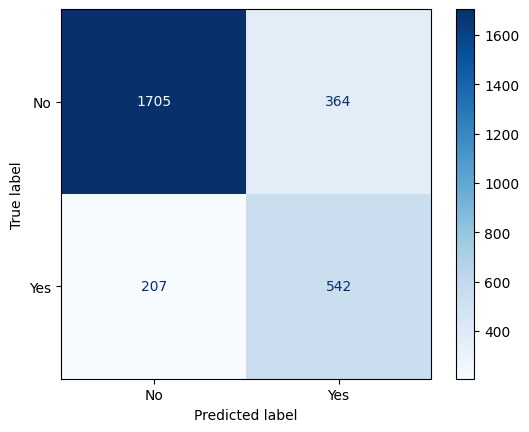


Classification Report for 60/40 split:
              precision    recall  f1-score   support

          No       0.89      0.82      0.86      2069
         Yes       0.60      0.72      0.65       749

    accuracy                           0.80      2818
   macro avg       0.74      0.77      0.76      2818
weighted avg       0.81      0.80      0.80      2818



In [105]:
# 60/40 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
pipeline.fit(X_train, y_train)
y_predict = pipeline.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_predict)
print("Confusion Matrix for 60/40 split:")
print(conf_matrix)

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap='Blues')
plt.show()

# Classification Report
class_report = classification_report(y_test, y_predict)
print("\nClassification Report for 60/40 split:")
print(class_report)

# Task 8
Generate a 2D decision boundary visualization or inspect model feature coefficients to interpret how the model separates churning customers from retained customers.